In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('C:/Users/lenovo/Desktop/Git project/hotel_booking_cleaned_data.csv')
df.head()

,Customer ID,Customer Country,Booking_ID,Hotel,City,Booking Date,Lead Time,Arrival Date,Adults,Childrens,...,No. of Week Nights,Total Nights Stay,Meal Type,Booking Status,Customer Cancel Count,Average Daily Rate,Market Segment,Reserved Room Type,Assigned Room Type,Special Request
0,CUST_570,India,INN00001,Resort Hotel,Hyderabad,20-Aug-23,342,27-Jul-24,2,0,...,5,7,Breakfast,0,1,135,Online Self / TA,Deluxe,Premium,0
1,CUST_164,UK,INN00002,Resort Hotel,Goa,20-Mar-23,405,28-Apr-24,2,0,...,3,4,Not Selected,1,1,0,Online Self / TA,Deluxe,Deluxe,0
2,CUST_420,India,INN00003,Resort Hotel,Mumbai,3-Sep-24,7,10-Sep-24,2,0,...,3,4,Breakfast,0,0,75,Direct,Standard,Standard,0
3,CUST_278,Australia,INN00004,City Hotel,Kochi,1-Aug-24,13,14-Aug-24,2,0,...,2,2,Breakfast,1,1,75,Online Self / TA,Standard,Standard,0
4,CUST_572,India,INN00005,City Hotel,Jaipur,31-Aug-24,14,14-Sep-24,2,0,...,2,3,Not Selected,1,2,98,Online Self / TA,Standard,Deluxe,1


In [8]:
# check info
df.info()
# check missing values
df.isnull().sum()
# remove missing values
df = df.dropna()
# remove duplicates
df.drop_duplicates(inplace=True)
# Convert string dates to datetime using correct format
df['Arrival Date'] = pd.to_datetime(df['Arrival Date'], format='%d-%b-%y')
df['Booking Date'] = pd.to_datetime(df['Booking Date'], format='%d-%b-%y')
#create new column for month
df['Month'] = df['Arrival Date'].dt.month


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer ID            1000 non-null   str  
 1   Customer Country       1000 non-null   str  
 2   Booking_ID             1000 non-null   str  
 3   Hotel                  1000 non-null   str  
 4   City                   1000 non-null   str  
 5   Booking Date           1000 non-null   str  
 6   Lead Time              1000 non-null   int64
 7   Arrival Date           1000 non-null   str  
 8   Adults                 1000 non-null   int64
 9   Childrens              1000 non-null   int64
 10  Total Guests           1000 non-null   int64
 11  No. of Weekend Nights  1000 non-null   int64
 12  No. of Week Nights     1000 non-null   int64
 13  Total Nights Stay      1000 non-null   int64
 14  Meal Type              1000 non-null   str  
 15  Booking Status         1000 non-null   int64
 16  

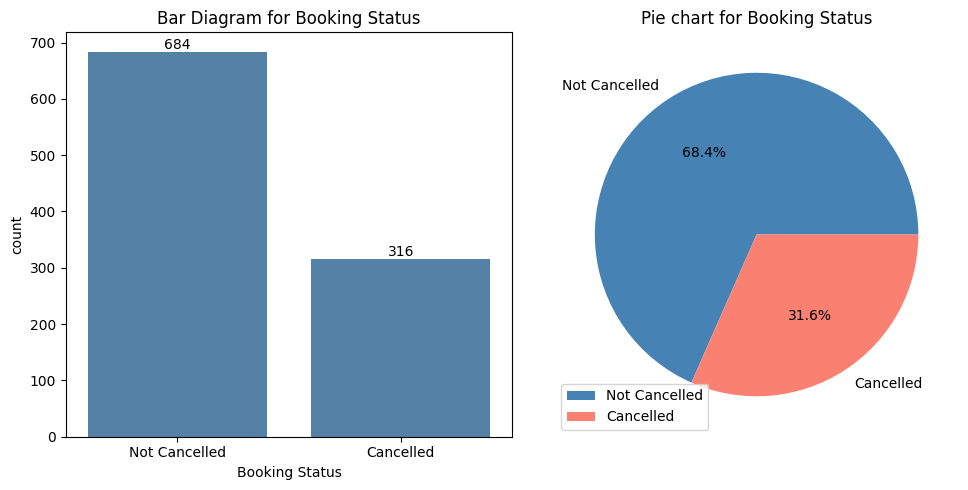

In [14]:
#Univariate Analysis of Booking Status Distribution
# Show both cleanly
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Countplot
ax = sns.countplot(x='Booking Status', data=df, ax=axes[0], color='steelblue')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Not Cancelled','Cancelled'])
for p in ax.patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
axes[0].set_title("Bar Diagram for Booking Status")
# Pie chart
counts = df['Booking Status'].value_counts()
axes[1].pie(counts,
            labels=['Not Cancelled','Cancelled'],
            autopct='%1.1f%%',
            colors=['steelblue','salmon'])
axes[1].set_title("Pie chart for Booking Status")
plt.legend()
plt.tight_layout()
plt.show()


## Booking Status Insight
Out of total bookings, 684(i.e 68.4%) bookings were not cancelled while 316 (i.e 31.6%)bookings were cancelled.

This indicates that the majority of customers complete their bookings successfully. 
However, a significant portion (around 31.6%) of bookings are cancelled, which suggests 
that cancellation is an important factor to consider in hotel booking analysis.

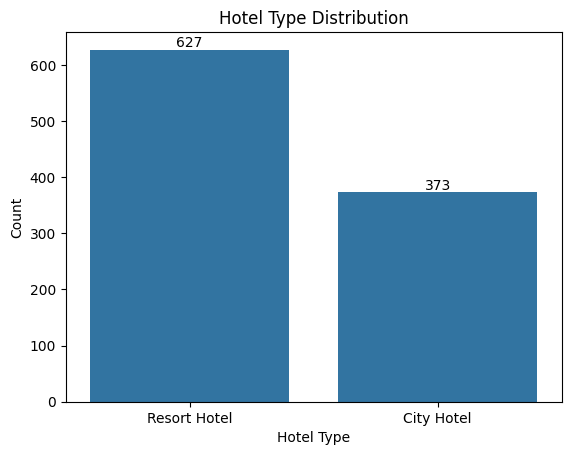

In [15]:
#Univariate Analysis of Hotel Type Distribution
# Countplot to show number of bookings for each hotel type
ax = sns.countplot(x='Hotel', data=df)
# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

## Hotel Type Insight
Out of total bookings, 627 bookings are for Resort Hotels while 373 bookings are for City Hotels.

This indicates that Resort Hotels are more preferred by customers compared to City Hotels. 
The higher number of bookings for Resort Hotels suggests that customers are more interested 
in leisure travel and vacation stays rather than city-based or business-related stays.

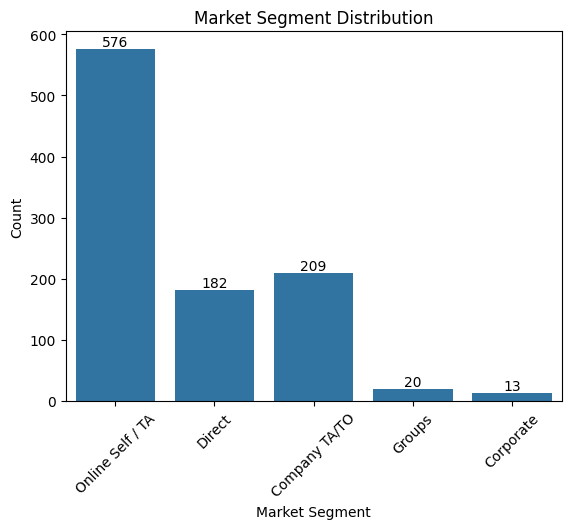

In [16]:

#Univariate Analysis of Market Segment Distribution
# Countplot to show number of bookings for each market segment
ax = sns.countplot(x='Market Segment', data=df)
# Add count labels on bars
ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Count")
plt.show()

## Market Segment Insight
Out of total bookings, Online TA has the highest bookings (576), followed by Company TA/TO (209) and Direct bookings (182). 
Other segments such as Groups (20) and Corporate (13) contribute very less to total bookings.

This indicates that most customers prefer booking through online travel agents, showing the importance of online platforms in hotel bookings, while corporate and group bookings are comparatively lower.

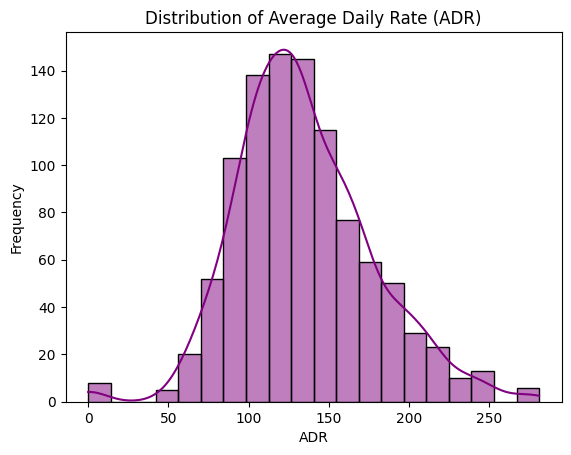

In [17]:
#Distribution of Average Daily Rate (ADR)
# Histogram shows how ADR values are distributed across bookings
sns.histplot(df['Average Daily Rate'], bins=20, kde=True, color='purple')
plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

## Average Daily Rate Insights
The ADR (Average Daily Rate) distribution is right-skewed, indicating that most bookings are concentrated in the mid-price range, mainly between ₹110 and ₹140. This represents the core pricing segment of the hotel business and shows that most customers prefer moderately priced stays.

A small number of bookings have very low or zero ADR, which may indicate complimentary stays or data anomalies, while a few high-value bookings above ₹180 represent premium segments. Overall, the pricing structure is stable, with most revenue generated from mid-range bookings and limited influence from extreme values.

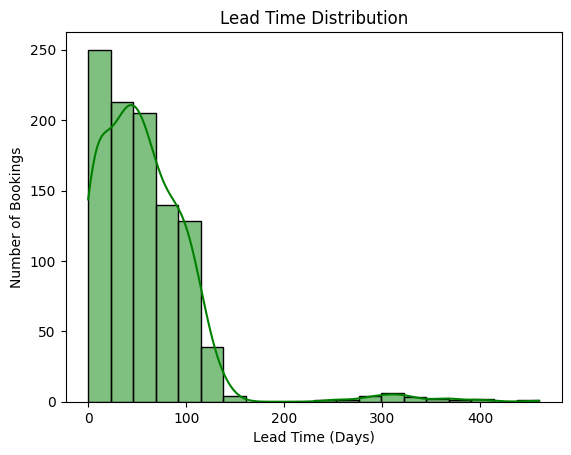

In [ ]:
#Lead Time Distribution
# Histogram shows how far in advance customers book their rooms
df.columns = df.columns.str.strip()   #remove extra spaces
sns.histplot(df['Lead Time'], bins=20, kde=True, color='green')
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.show()

## Lead Time Insights
The Lead Time distribution is strongly right-skewed, showing that most customers book their stays within a short period before arrival (0–50 days). This indicates a preference for last-minute or short-term booking behavior.

As lead time increases, the number of bookings decreases significantly, with very few long-advance bookings beyond 100 days and a few rare outliers above 300 days. Overall, the hotel mainly receives short-to-medium term bookings with limited long-term reservations.

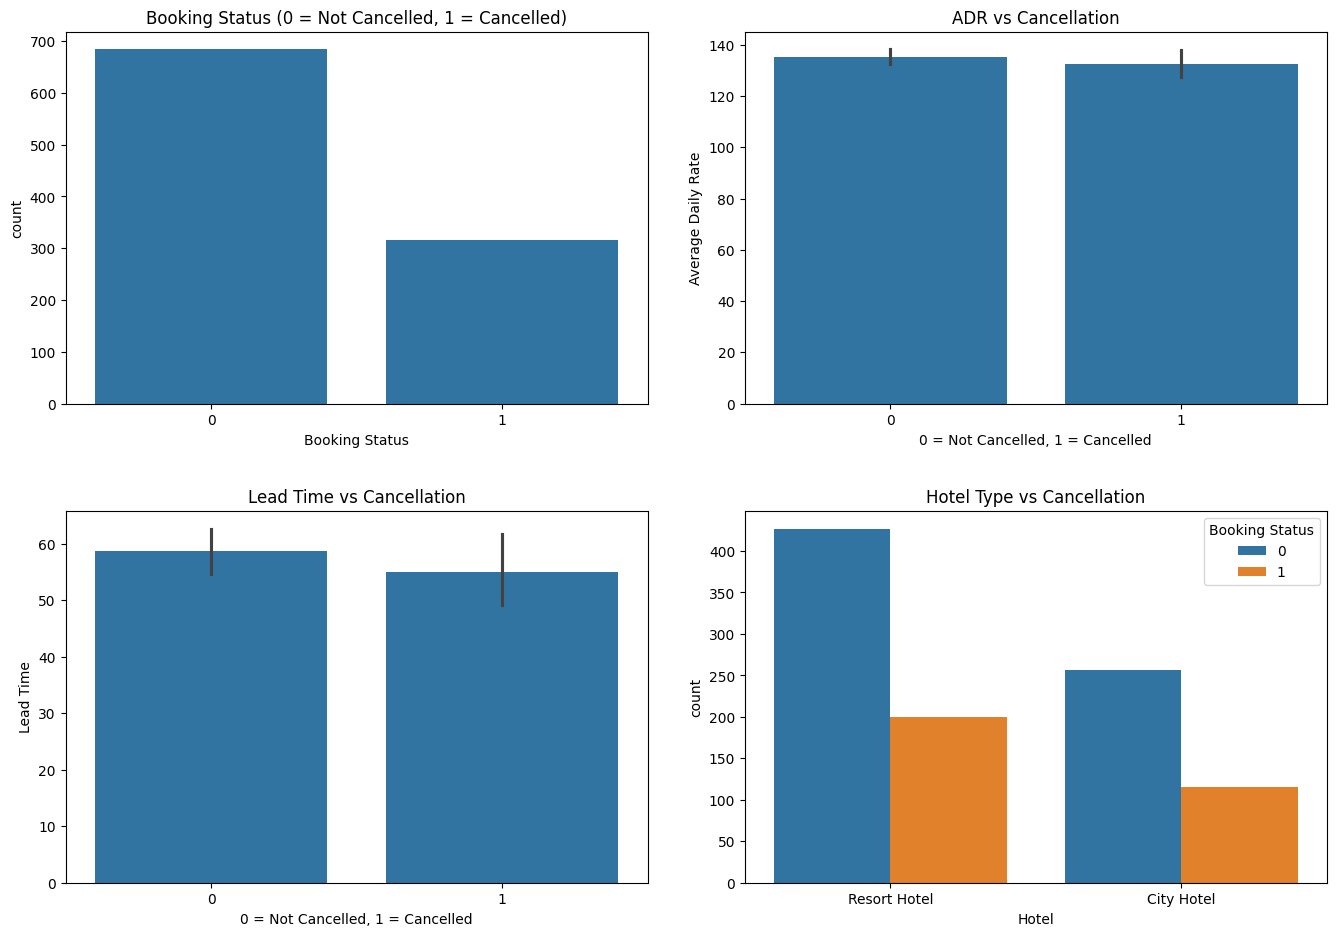

In [ ]:
#Cancellation Behavior Analysis
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Booking Status
sns.countplot(x='Booking Status', data=df, ax=axes[0,0])
axes[0,0].set_title("Booking Status (0 = Not Cancelled, 1 = Cancelled)")

# 2. ADR vs Booking Status
sns.barplot(x='Booking Status', y='Average Daily Rate', data=df, ax=axes[0,1])
axes[0,1].set_title("ADR vs Cancellation")
axes[0,1].set_xlabel("0 = Not Cancelled, 1 = Cancelled")

# 3. Lead Time vs Booking Status
sns.barplot(x='Booking Status', y='Lead Time', data=df, ax=axes[1,0])
axes[1,0].set_title("Lead Time vs Cancellation")
axes[1,0].set_xlabel("0 = Not Cancelled, 1 = Cancelled")

# 4. Hotel Type vs Booking Status
sns.countplot(x='Hotel', hue='Booking Status', data=df, ax=axes[1,1])
axes[1,1].set_title("Hotel Type vs Cancellation")

plt.tight_layout(pad=3.0)
plt.show()

## Cancellation Behavior Analysis Insights
Around 68% of bookings are not cancelled, while 31–32% are cancelled, showing a moderate cancellation rate. ADR is almost similar for both groups, indicating that price does not strongly influence cancellations. Lead time also shows very little difference between cancelled and non-cancelled bookings.

Resort Hotels have higher bookings and relatively fewer cancellations compared to City Hotels. This suggests that hotel type and customer segment have a stronger impact on cancellation behavior than price or booking lead time.

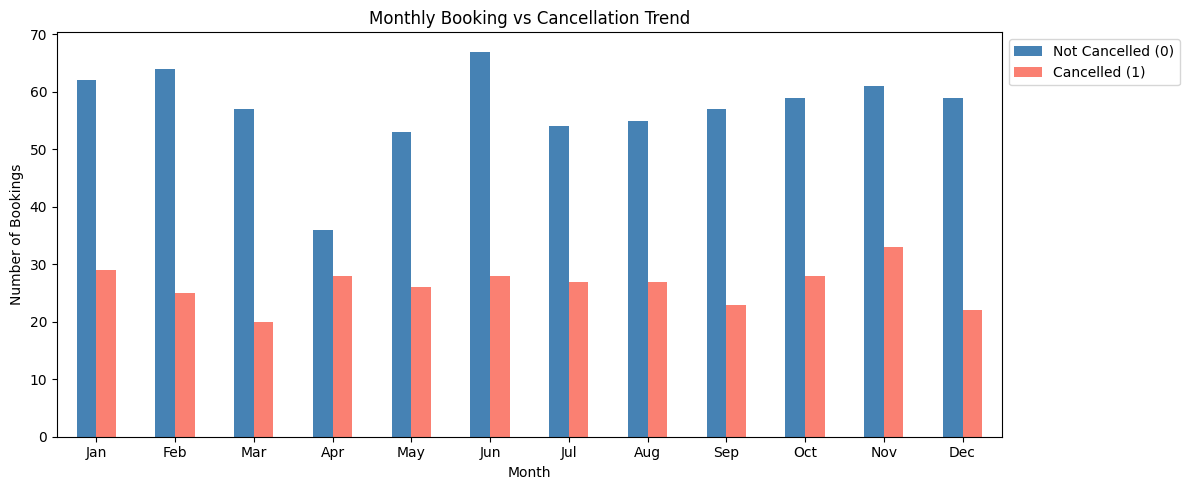

In [ ]:
#Monthly booking and Cancellation Analysis
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# Create summary table
monthly_data = df.groupby('Month')['Booking Status'].value_counts().unstack().fillna(0)
# Ensure correct order
monthly_data = monthly_data.reindex(month_order)
# Plot
ax = monthly_data.plot(kind='bar', figsize=(12,5), color=['steelblue','salmon'])
plt.title("Monthly Booking vs Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
# Legend 
plt.legend(['Not Cancelled (0)', 'Cancelled (1)'],
           loc='upper left',
           bbox_to_anchor=(1,1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Monthly Booking and Cancellation Analysis
June month shows the highest booking volume, indicating peak demand and strong travel activity. November month records the highest cancellations, making it the most risky month for lost revenue. March month shows relatively low cancellations, making it the most stable and reliable month.

Overall, mid-year months (June–August) show steady performance with high bookings and stable cancellations, while November month requires attention due to higher cancellation rates.

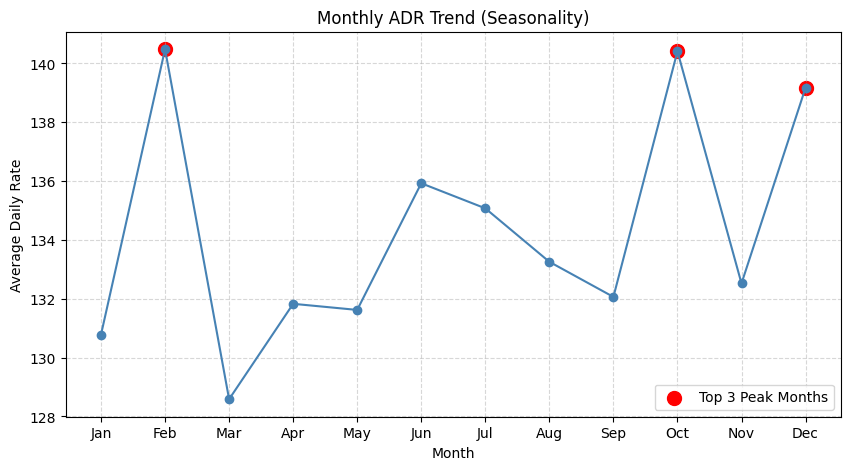

In [ ]:
# Monthly ADR Trend 
plt.figure(figsize=(10,5))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_adr = df.groupby('Month')['Average Daily Rate'].mean().reindex(month_order)
# Line plot
plt.plot(monthly_adr.index, monthly_adr.values, marker='o', color='steelblue')
plt.title("Monthly ADR Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Daily Rate")
plt.grid(True, linestyle='--', alpha=0.5)
# Highlight Top 3 peak months
top3 = monthly_adr.sort_values(ascending=False).head(3)
plt.scatter(top3.index, top3.values, color='red', s=100, label='Top 3 Peak Months')
plt.legend()
plt.show()

## Monthly ADR Trend Insights
The Monthly ADR Trend shows clear seasonality in pricing. February and October record the highest ADR (~140), indicating peak demand and premium pricing periods, while March shows the lowest ADR (~128), reflecting a low-demand season.

Overall, ADR fluctuates significantly across months, with (Oct–Jan) showing stronger revenue performance. This indicates that hotel pricing is highly demand-driven and varies based on seasonal travel patterns.